# Artificial Neural Network(ANN) with PyTorch but optimized than [6_ANN_PyTorch.ipynb](https://colab.research.google.com/drive/1bAK-GWDU3YEQ_h2dOo7Fnl_F3rANo59x?usp=sharing)

Creating a ANN using PyTorch with a Fashion Mnist datasets of images.

Training the Neural Network model on GPU with PyTorch

**Architecture of the Neural Network :**
1. Input Layer => input features (i,e 784 neurons)
2. Hidden Layer 1 => ReLU(128 neurons)
3. Hidden Layer 2 => ReLU(64 neurons)
4. Output Layer => softmax (10 neurons)

#### Optimization Notes

> Earlier we trained the neural network model and after checking for the difference between the accuracy of training data and test data is comparatively more so we can assume that model is overfitted towards training data.


So below are the few technqiues using which we can reduce minimize the gap between the train and test data accuracy which means we can reduce the overfitting of the neural network model on the training data

1. Adding More data for training
2. Reducing the complexity of Neural Network architecture
3. Regularization
4. Dropouts
5. Data Augmentation
6. Batch Normalization
7. Early Stopping


*Here in our use case :*

❌ 1. We have limited number of fashion mnist images dataset. So we have to eliminate this option.

❌ 2.  Already our Neural Network is already simple and not that much complex which may leads to overfitting.

✅ 3. Regularization : In this in the loss function we add the penalty , so that our model tries to reduce the loss and also the penalty . So by this the overfitting of the model will be reduced.

✅ 4. Dropouts : In this , at the time of training we will turn off some of the neurons in the hidden layers.

❌ 5. Data Augmentation : In this we will apply some of the transformation on the images(like rotating, resizng ..etc) so that we will get variety of data which may also helps to reduce overfitting. But it will works better when we are working with Convolutional Neural Network (CNN).

✅ 6. Batch Normalization : In this it will improve the stability during the training.

❌ 7. Early Stopping : In this we will stop the training the model in between if we observe that there is no improvement in the loss as we proceed with epochs. This may not help for our usecase.


So here we are using only this :
1. **Dropouts :**
    - This is applied to hidden layers.
    - Applied after applying the activation function.
    - Here we have *p(ex : p=0.5)* parameter , which randomly turns off *p%* neurons in the hidden layer during each forward pass
    - This also has a Regularization effect
    - During the evaluation mode dropouts is not used.
    - Function or syntax : nn.Dropout(p=0.5)
2. **Batch Normaliztion :**
    - It is typically applied to hidden layers of a neural network , but not to the output layers
    - Applied after linear layer and before actiavtion function in the neural network
    - It normalizes activation
    - Includes learnable parameters
    - Improves training stability
    - It also has Regularization effect
    - At the evaluation time we dont calculate the batch normalization rather we use the same used at training time.
    - Function or syntax : nn.BatchNorm1d(output_weights_of_the_current_layers:int)
3. **Regularization :**
    - Here we use ***L2 Regularization***
    - Regularization is applied on the model weights to penalize the large values and encourage  smaller, more generalizable weights.
    - In this it adds the penalty term to loss function in L2 Regularization.
    - Using weight_decay we can implement L2 regularization.
    - It will not effect the bias terms.
    - It is done only at the training time.
    - Function or syntax : In optimizer we have one parameter called (weight_decay=1e-4)

> #### **Conclusion :**
  *Here we have noticed that the gap between the accuracy of the training and test dataset is reduced by 50% means the ovefitting is being reduced at some extent in our ANN model.*

### Step-1 : Loading dataset

In [1]:
#  Import Libraries
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


In [2]:
# Seed random for reproducibility
torch.manual_seed(42)

In [3]:
#------------------------Checking the availablity of the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device : {device}")

Using Device : cuda


In [4]:
# Loading Dataset
df = pd.read_csv("/content/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(60000, 785)

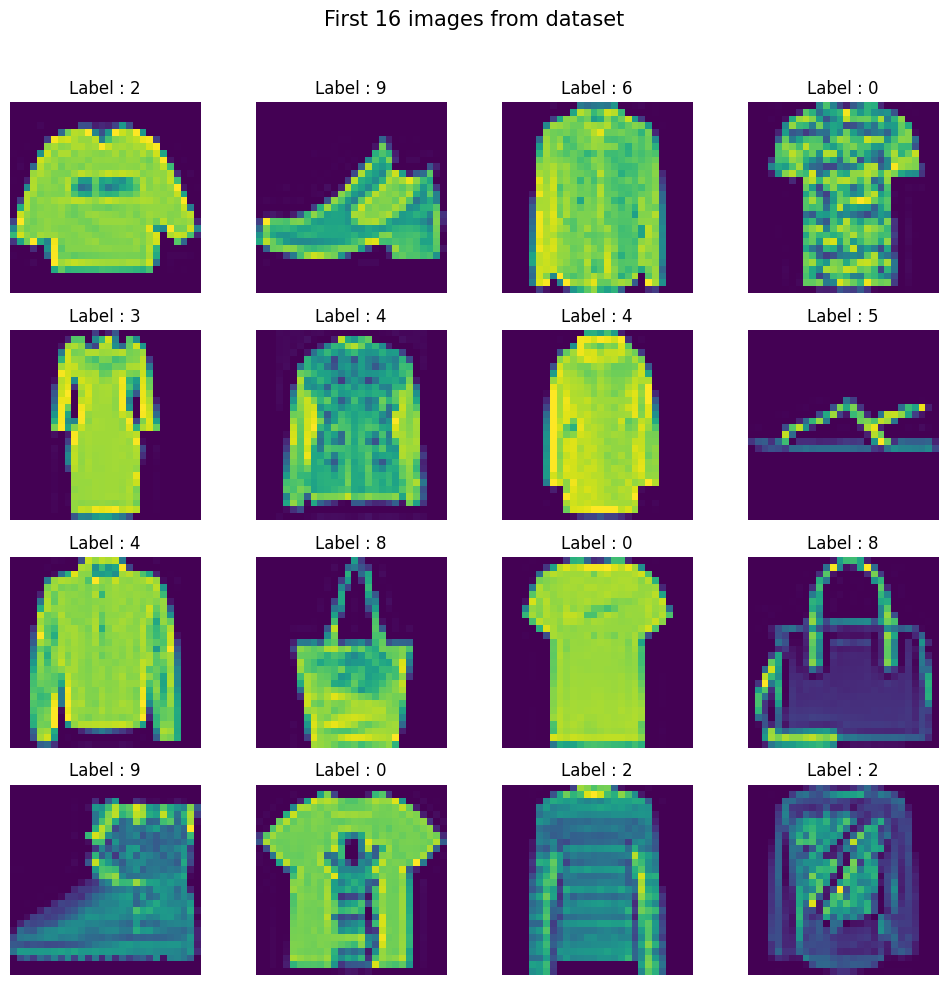

In [6]:
# Creating a simple 4x4 grid of images
fig, axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images from dataset",fontsize=15)

# Plot first 16 images from the dataset
for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28) # Reshape to 28x28
  ax.imshow(img) # Display in grayscale
  ax.axis('off') # Remove axis for cleaner look
  ax.set_title(f"Label : {df.iloc[i,0]}") #show the label

plt.tight_layout(rect=[0,0,1,0.96]) # Adjust layout to fit the title
plt.show()



#### 1.1 . Train Test Split

In [7]:
# Diving dataset into features and label
X = df.iloc[:,1:].values #  features = column 1 to end
y = df.iloc[:,0].values # label = column 0

In [8]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape : (48000, 784)
X_test shape : (12000, 784)
y_train shape : (48000,)
y_test shape : (12000,)


In [10]:
# Scaling the features
# Because as our dataset is a image dataset in which all the feature values is  between 0 to 255 , So to make it between 0 to 1 we are dividing it by 255
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

### 2. Creating Dataset class and Dataloader object

In [12]:
# Creating a custom Dataset class
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32) # Converting from numpy arrays to PyTorch tensor (float32)
    self.labels = torch.tensor(labels,dtype=torch.long) # Converting from Numpy arrays to PyTorch tensor(long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]

In [13]:
# Dataset object for train and test data
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [14]:
train_dataset

In [15]:
len(train_dataset) # __len__

48000

In [16]:
train_dataset[9] # __getitem__

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [17]:
# Creating Train and Test Dataloader

train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_dataloader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

In [18]:
train_dataloader

### 3. Defining the network and training the model

In [19]:
# Defining the NN Model

class MyNNModel(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        # Hidden Layer 1
        nn.Linear(in_features=num_features,out_features=128), # Here num_features= 784

        nn.BatchNorm1d(128), # Batch Normalization (128 = num of output weights of the current layer)
        nn.ReLU(), # Activation Function
        nn.Dropout(p=0.3), # Dropouts of p=0.3 i,e p=30%

        # Hidden Layer 2
        nn.Linear(in_features=128,out_features=64),
        nn.BatchNorm1d(64), # Batch Normalization (64 = num of output weights of the current layer)
        nn.ReLU(), # ACtivation Function
        nn.Dropout(p=0.3), # Dropouts of p=0.3 i,e p=30%

        nn.Linear(in_features=64,out_features=10), # Ouput Layer and activation fucntion(softmax) will be applied automatically by cross entropy loss
    )

  # Forward Propogation
  def forward(self,x):
    return self.model(x)

In [20]:
# Defining important parameters
learning_rate = 0.1
epochs = 100

In [21]:
# Instantiate model
model = MyNNModel(X_train.shape[1])

# ------------------------Moving the model to gpu
model = model.to(device)
# Loss Function - Cross Entropy Loss
loss_func = nn.CrossEntropyLoss()

# Optimizer
# Here weight_decay is for L2-Regularization
optimizer = optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

#### 3.2 Training the model

In [22]:
# Training Loop

import time

start_time = time.time()
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features,batch_labels in train_dataloader:


    # ------------------------Moving the batch features and batch labels to GPU
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    # Forward Propogation(pass)
    out = model(batch_features)

    # Loss
    loss = loss_func(out,batch_labels)

    # Clear Gradients
    optimizer.zero_grad()

    # Backward Propogation
    loss.backward()

    # Parameters Updates
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_epoch_loss = total_epoch_loss/len(train_dataloader)

  print(f"Epoch : {epoch + 1}, Loss : {avg_epoch_loss}")



end_time = time.time()

print(f"Total Time taken to train the model : {end_time - start_time}")

Epoch : 1, Loss : 0.6249084657629331
Epoch : 2, Loss : 0.49199690653880435
Epoch : 3, Loss : 0.45562089485426743
Epoch : 4, Loss : 0.43380642544229825
Epoch : 5, Loss : 0.41715061584611735
Epoch : 6, Loss : 0.40564093277355034
Epoch : 7, Loss : 0.3941608931571245
Epoch : 8, Loss : 0.38580174928406874
Epoch : 9, Loss : 0.3743983890265226
Epoch : 10, Loss : 0.3725726637095213
Epoch : 11, Loss : 0.36783315147956214
Epoch : 12, Loss : 0.3572052289446195
Epoch : 13, Loss : 0.35052060889204345
Epoch : 14, Loss : 0.3449219484726588
Epoch : 15, Loss : 0.34472562207778296
Epoch : 16, Loss : 0.33732124184072015
Epoch : 17, Loss : 0.3344038988550504
Epoch : 18, Loss : 0.3302020480086406
Epoch : 19, Loss : 0.33063985937833784
Epoch : 20, Loss : 0.3262277270356814
Epoch : 21, Loss : 0.3208496819138527
Epoch : 22, Loss : 0.3183093272894621
Epoch : 23, Loss : 0.3225850373158852
Epoch : 24, Loss : 0.31459670132398604
Epoch : 25, Loss : 0.31343053522954384
Epoch : 26, Loss : 0.31424527982374034
Epoch :

Epoch : 100, Loss : 0.062096262525573064

### 4. Evaluation

In [23]:
#  Setting mode to evaluation mode(Optional)
model.eval()

MyNNModel(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
# Evaluating the model on test data

total = 0
correct = 0

with torch.no_grad():
  for batch_features,batch_labels in test_dataloader:

     # ------------------------Moving the batch features and batch labels to GPU
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    outputs = model(batch_features)

    _,predicted = torch.max(outputs,1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()


print(f"Accuracy : {correct/total}")

Accuracy : 0.88325


In [25]:
# Evaluating the model on training data to check for overfitting

total = 0
correct = 0

with torch.no_grad():
  for batch_features,batch_labels in train_dataloader:

     # ------------------------Moving the batch features and batch labels to GPU
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    outputs = model(batch_features)

    _,predicted = torch.max(outputs,1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()


print(f"Accuracy : {correct/total}")

Accuracy : 0.9325416666666667
